# 🦠 Analyse Avancée des Données COVID-19 (Gold Layer)
Ce notebook explore les données préparées par le pipeline de données, stockées dans MinIO au format Parquet.
L'objectif est d'extraire des insights avancés : corrélations, tendances temporelles et impact de la vaccination sur la mortalité.

In [4]:
!pip install matplotlib seaborn

  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)


In [5]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pyspark.sql import SparkSession
from pyspark.sql.functions import col, corr, lag, window
from pyspark.sql.window import Window

# Améliorer l'affichage des graphiques
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")
%matplotlib inline

## 1. Initialisation de la Session Spark (MinIO)

In [6]:
# Utilisation du module centralisé pour Spark (nécessite que covid_data_analysis soit installé avec pip install -e .)
from src.common.spark_config import create_spark_session
from src.common.utils import load_env

env = load_env()
spark = create_spark_session()
spark

:: loading settings :: url = jar:file:/home/belaid-abderrahim/Bureau/Master/S2/Big%20Data/tps/covid_data_analysis/env_spark/lib/python3.13/site-packages/pyspark/jars/ivy-2.5.3.jar!/org/apache/ivy/core/settings/ivysettings.xml
Ivy Default Cache set to: /home/belaid-abderrahim/.ivy2.5.2/cache
The jars for the packages stored in: /home/belaid-abderrahim/.ivy2.5.2/jars
org.apache.hadoop#hadoop-aws added as a dependency
software.amazon.awssdk#bundle added as a dependency
:: resolving dependencies :: org.apache.spark#spark-submit-parent-056a486d-9d75-49c6-b6e9-7dd170c38657;1.0
	confs: [default]
	found org.apache.hadoop#hadoop-aws;3.4.2 in central
	found software.amazon.awssdk#bundle;2.29.52 in central
	found software.amazon.s3.analyticsaccelerator#analyticsaccelerator-s3;1.2.1 in central
	found org.wildfly.openssl#wildfly-openssl;2.1.4.Final in central
:: resolution report :: resolve 1378ms :: artifacts dl 20ms
	:: modules in use:
	org.apache.hadoop#hadoop-aws;3.4.2 from central in [default]

Spark session created with app name: CovidDataAnalysis


## 2. Chargement des Données Gold

In [8]:
gold_bucket = env.get("MINIO_BUCKET_GOLD", "gold")

# Chargement des agrégations mensuelles
vax_monthly = spark.read.parquet(f"s3a://{gold_bucket}/vaccination_monthly")
mort_monthly = spark.read.parquet(f"s3a://{gold_bucket}/mortality_monthly")
cases_monthly = spark.read.parquet(f"s3a://{gold_bucket}/cases_monthly")
test_monthly = spark.read.parquet(f"s3a://{gold_bucket}/testing_monthly")

In [9]:
test_monthly.show()

+-----------+----+-----+---------+---------------+---------------+-----------------+------------+
|   location|year|month|max_tests|total_new_tests|avg_daily_tests|avg_positive_rate|record_count|
+-----------+----+-----+---------+---------------+---------------+-----------------+------------+
|AFGHANISTAN|2020|    1|      0.0|            0.0|            0.0|              0.0|          27|
|AFGHANISTAN|2020|    2|      0.0|            0.0|            0.0|              0.0|          29|
|AFGHANISTAN|2020|    3|      0.0|            0.0|            0.0|              0.0|          31|
|AFGHANISTAN|2020|    4|      0.0|            0.0|            0.0|              0.0|          30|
|AFGHANISTAN|2020|    5|      0.0|            0.0|            0.0|              0.0|          31|
|AFGHANISTAN|2020|    6|      0.0|            0.0|            0.0|              0.0|          30|
|AFGHANISTAN|2020|    7|      0.0|            0.0|            0.0|              0.0|          31|
|AFGHANISTAN|2020|  

## 3. Analyse Globale : Vaccination vs Mortalité (Série Temporelle)

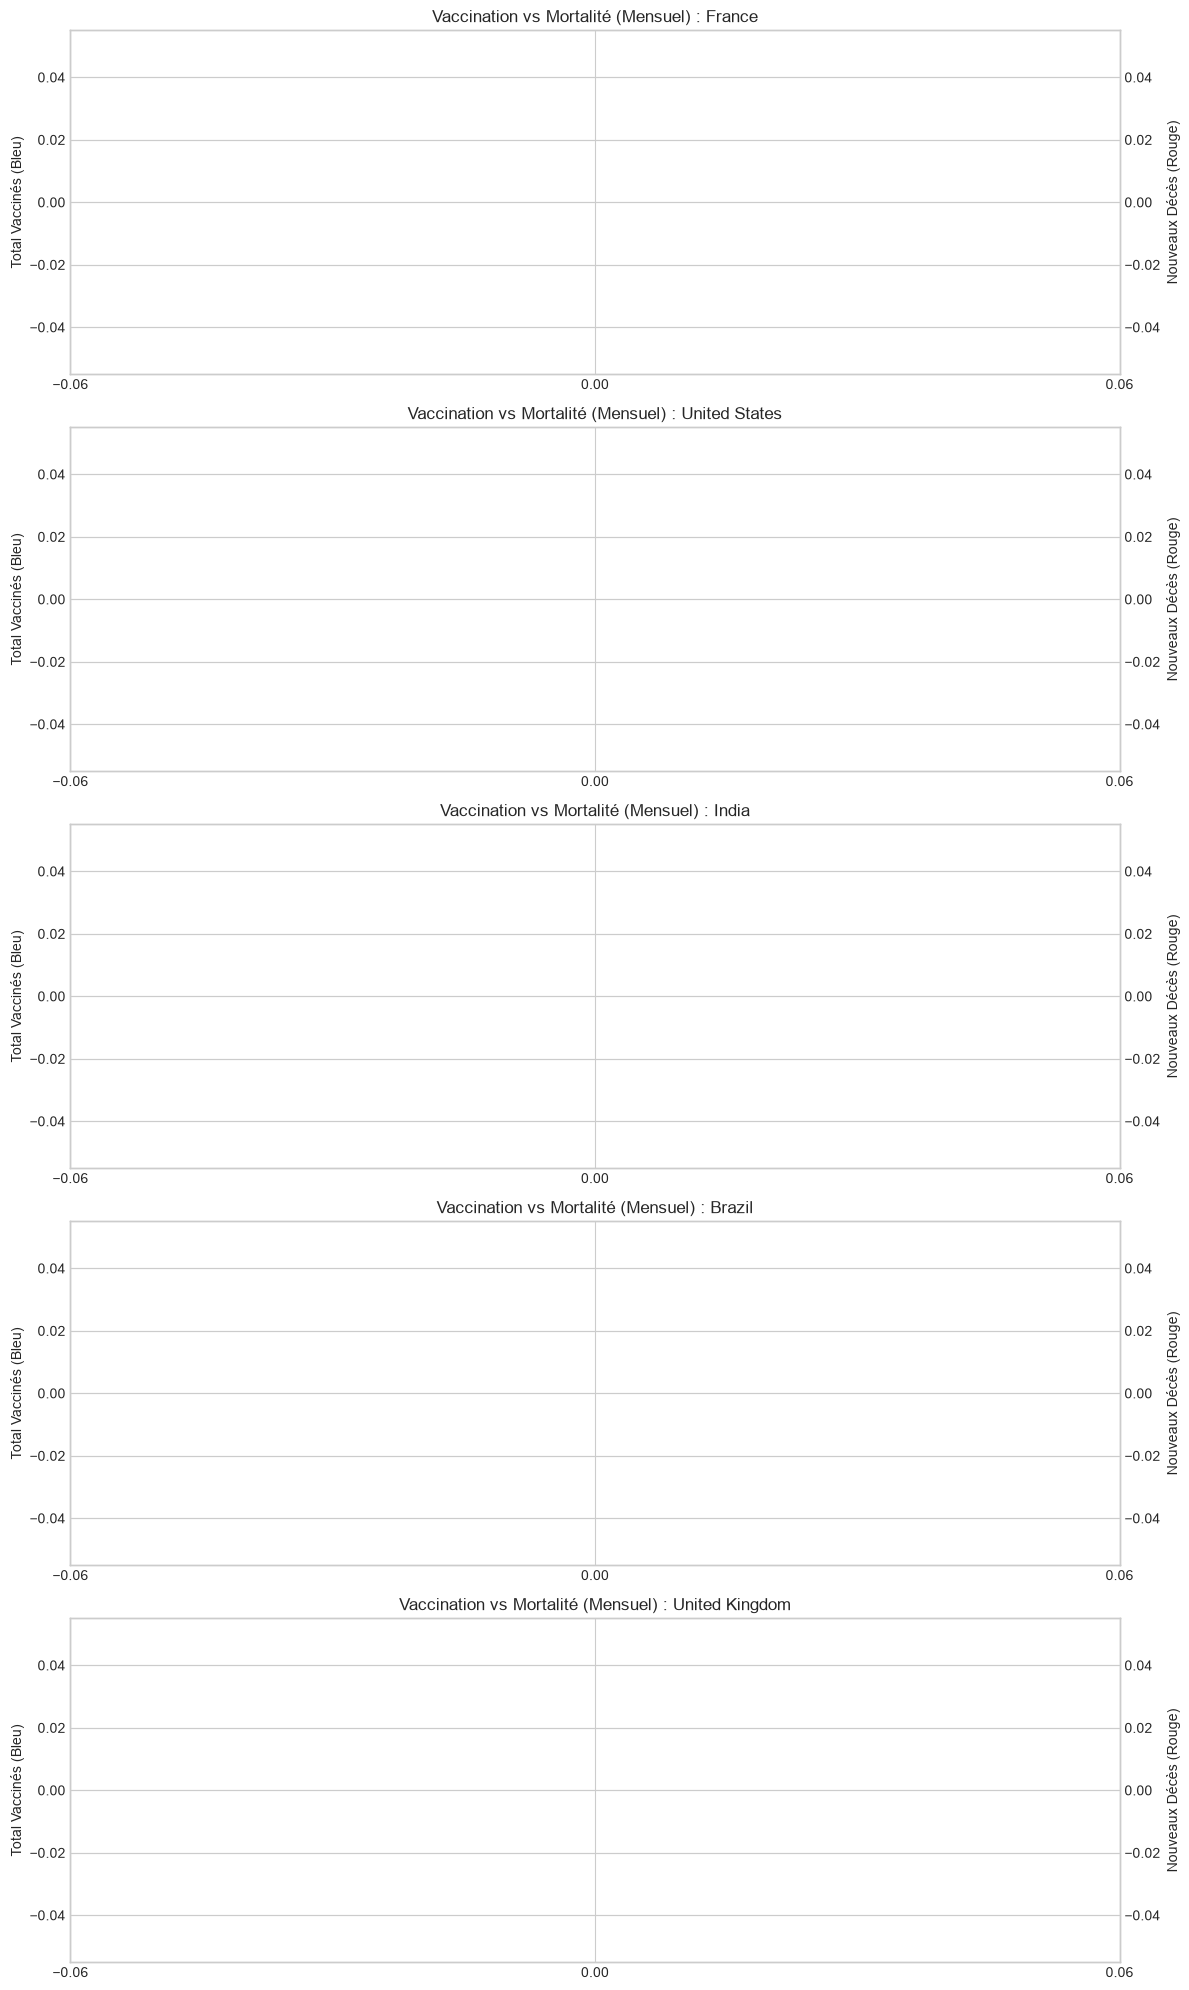

In [10]:
# Jointure des données mondiales
df_combined = vax_monthly.join(mort_monthly, ["location", "year", "month"], "inner")

# Pour l'exemple, prenons quelques pays spécifiques pour éviter le bruit global.
pays_cibles = ["France", "United States", "India", "Brazil", "United Kingdom"]
df_pays = df_combined.filter(col("location").isin(pays_cibles)).orderBy("year", "month")

# Conversion en Pandas pour la visualisation Matplotlib
pdf = df_pays.select("location", "year", "month", "max_fully_vaccinated", "total_new_deaths").toPandas()
pdf['date'] = pdf['year'].astype(str) + '-' + pdf['month'].astype(str).str.zfill(2)

fig, axes = plt.subplots(len(pays_cibles), 1, figsize=(12, 4 * len(pays_cibles)), sharex=False)
for ax, pays in zip(axes, pays_cibles):
    subset = pdf[pdf['location'] == pays].sort_values('date')
    
    ax2 = ax.twinx()
    ax.plot(subset['date'], subset['max_fully_vaccinated'], color='blue', label='Personnes Vaccinées', linewidth=2)
    ax2.plot(subset['date'], subset['total_new_deaths'], color='red', label='Nouveaux Décès', linestyle='--')
    
    ax.set_title(f'Vaccination vs Mortalité (Mensuel) : {pays}')
    ax.set_ylabel('Total Vaccinés (Bleu)')
    ax2.set_ylabel('Nouveaux Décès (Rouge)')
    ax.set_xticks(ax.get_xticks()[::3])

plt.tight_layout()
plt.show()

## 4. Analyse Avancée : Corrélation avec Décalage Temporel (Time-Lag)
La vaccination met du temps à faire effet sur la mortalité. Calculons la corrélation entre les décès et la vaccination avec un décalage (lag) d'un à deux mois.

In [11]:
# Création d'une fenêtre temporelle par pays
windowSpec = Window.partitionBy("location").orderBy("year", "month")

# Ajout des colonnes avec décalage : les décès du mois M sont comparés à la vaccination des mois précédents
df_lagged = df_combined.withColumn("deaths_lag_1", lag("total_new_deaths", -1).over(windowSpec)) \
                       .withColumn("deaths_lag_2", lag("total_new_deaths", -2).over(windowSpec))

# Filtrage pour enlever les valeurs nulles générées par le lag
df_lagged_clean = df_lagged.filter(col("deaths_lag_2").isNotNull())

print("Corrélation Globale (Mois courant) :", df_lagged_clean.stat.corr("max_fully_vaccinated", "total_new_deaths"))
print("Corrélation Globale (1 Mois de décalage) :", df_lagged_clean.stat.corr("max_fully_vaccinated", "deaths_lag_1"))
print("Corrélation Globale (2 Mois de décalage) :", df_lagged_clean.stat.corr("max_fully_vaccinated", "deaths_lag_2"))

Corrélation Globale (Mois courant) : 0.2257756934336285
Corrélation Globale (1 Mois de décalage) : 0.199097949877225
Corrélation Globale (2 Mois de décalage) : 0.17572570799489087


## 5. Machine Learning : Clustering des Pays selon le Taux de Positivité
Utilisons l'algorithme KMeans de Spark MLlib pour regrouper les pays en fonction de leur volume de cas et du taux moyen de positivité.

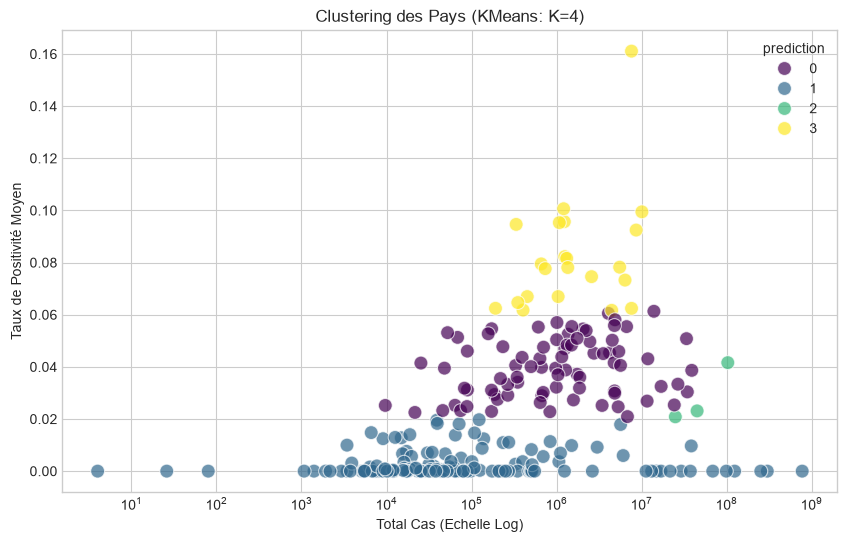

In [14]:
from pyspark.ml.feature import VectorAssembler, StandardScaler
from pyspark.ml.clustering import KMeans
from pyspark.sql import functions as function

# Préparation des données ML
df_ml = test_monthly.join(cases_monthly, ["location", "year", "month"], "inner")

# Agrégation par pays
df_ml_agg = df_ml.groupBy("location").agg(
    function.avg("avg_positive_rate").alias("avg_positive_rate"),
    function.sum("total_new_tests").alias("total_tests"),
    function.sum("total_new_cases").alias("total_cases")
).filter(col("total_tests").isNotNull() & col("total_cases").isNotNull() & col("avg_positive_rate").isNotNull())

# Feature Engineering : Vectorisation
assembler = VectorAssembler(inputCols=["avg_positive_rate", "total_tests", "total_cases"], outputCol="features")
feature_df = assembler.transform(df_ml_agg)

# Feature Scaling (Standardisation car les échelles varient drastiquement)
scaler = StandardScaler(inputCol="features", outputCol="scaledFeatures", withStd=True, withMean=True)
scalerModel = scaler.fit(feature_df)
scaled_df = scalerModel.transform(feature_df)

# Apprentissage : KMeans avec K=4 clusters
kmeans = KMeans().setK(4).setSeed(42).setFeaturesCol("scaledFeatures")
model = kmeans.fit(scaled_df)

# Ajout des prédictions
predictions = model.transform(scaled_df)

# Visualisation des clusters générés par Spark
pdf_clusters = predictions.select("location", "avg_positive_rate", "total_cases", "prediction").toPandas()

plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=pdf_clusters, 
    x="total_cases", 
    y="avg_positive_rate", 
    hue="prediction", 
    palette="viridis",
    s=100, alpha=0.7
)
plt.title('Clustering des Pays (KMeans: K=4)')
plt.xscale('log')
plt.xlabel('Total Cas (Echelle Log)')
plt.ylabel('Taux de Positivité Moyen')
plt.show()